In [1]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from matplotlib.cm import ScalarMappable

from models import CondSM

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


In [2]:
state_dict = torch.load('/gpfs/bwfor/work/ws/hd_gy283-my_data/models/sm_uni_na=200.pth', weights_only=False, map_location='cpu')

model = CondSM(state_dict['layer_dims'], dropout_p=state_dict['dropout'], batch_norm=state_dict['batch_norm'])
model.load_state_dict(state_dict['model_state_dict'])
print('model loaded')

model loaded


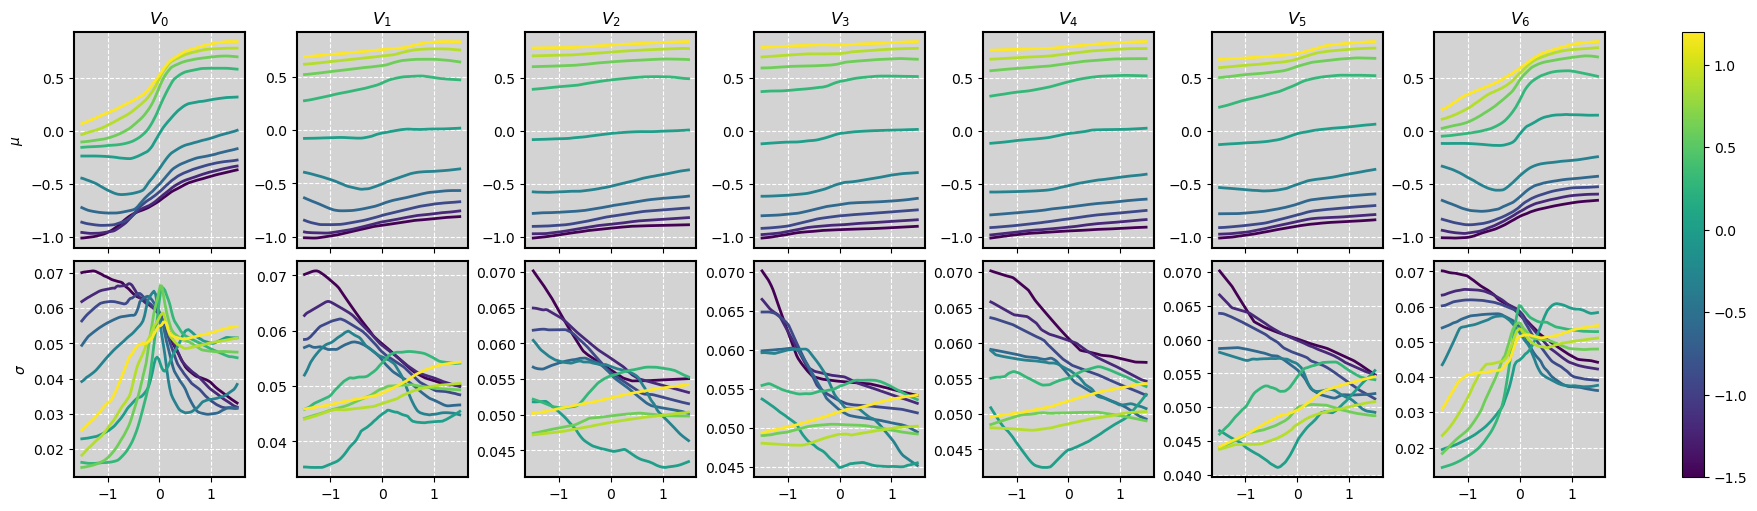

In [8]:
num_voltages = model.layer_dims[0]
num_outputs = model.layer_dims[-1]

N = 100
voltage_range = torch.linspace(-1.5, 1.5, N)

v_quantiles = torch.arange(-1.5, 1.5, 0.3)

e_indices = [i for i in range(num_voltages)]

fig, ax = plt.subplots(nrows=2, ncols=num_voltages, figsize=(2.5 * num_voltages, 5), constrained_layout=True)

cmap = plt.get_cmap('viridis')
norm = plt.Normalize(vmin=v_quantiles[0], vmax=v_quantiles[-1])
sm = ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])

cbar = fig.colorbar(sm, ax=ax.ravel().tolist())

model.eval()
for i in range(num_voltages):
    for v_q in v_quantiles:
        input_tensor = torch.empty(N, num_voltages, dtype=torch.float32)
        input_tensor[..., [col for col in range(num_voltages) if col != i]] = v_q
        input_tensor[:, i] = voltage_range

        I = model(input_tensor)
        mu = I[..., 0].detach().numpy()
        std = np.log1p(np.exp(I[..., 1].detach().numpy()))

        if i == 0:
            ax[0, i].set_ylabel(r'$\mu$')
            ax[1, i].set_ylabel(r'$\sigma$')

        ax[0, i].plot(voltage_range, mu, color=cmap(norm(v_q)), lw=2.0)
        ax[1, i].plot(voltage_range, std, color=cmap(norm(v_q)), lw=2.0)

        ax[0, i].tick_params(labelbottom=False)
        ax[0, i].set_title(rf'$V_{i}$')
        
        ax[0, i].set_facecolor('lightgrey')
        ax[1, i].set_facecolor('lightgrey')

        ax[0, i].spines[:].set_linewidth(1.5)
        ax[1, i].spines[:].set_linewidth(1.5)

        ax[0, i].grid(True, which='both', c='w', ls='dashed')
        ax[1, i].grid(True, which='both', c='w', ls='dashed')